# Marge Initiale — Approche Cash-Flow Mapping (CFM)

Ce notebook implémente le calcul de marge initiale selon l’approche **Cash-Flow Mapping (CFM)**.

Contrairement à la Full Revaluation (FR), qui revalorise chaque obligation sous chaque scénario, la CFM transforme d’abord les cash-flows du portefeuille en **expositions sur les piliers de la courbe zéro-coupon**. Les PnL sous scénarios sont ensuite calculés en appliquant directement les returns des piliers à ces expositions mappées.

**Pipeline :**

1. Chargement et nettoyage de la courbe zéro-coupon.
2. Construction des prix ZC, des returns historiques, des volatilités EWMA et des scénarios.
3. Génération des cash-flows obligataires du portefeuille.
4. Mapping CFM des cash-flows sur les piliers voisins de la courbe ZC.
5. Agrégation des expositions mappées par pilier.
6. Calcul des PnL CFM sous scénarios FHS scalés et stress non scalés.
7. Calcul de l’Expected Shortfall puis de la marge initiale CFM.
8. Vérification analytique de l’écart élémentaire FR vs CFM sur un cash-flow.


## 0. Setup et imports

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT =', ROOT)

/home/jellilm/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


ROOT = /home/jellilm/Desktop/Stage_addons/IM_pipeline./IM_pipeline


In [2]:
from src.config import ModelConfig
from src.market_data.loader import load_zero_coupon_curve
from src.market_data.cleaner import clean_zero_coupon_curve
from src.market_data.curve import get_curve_at_date
from src.risk.risk_factors import build_zero_coupon_price_matrix, compute_historical_returns
from src.risk.ewma import get_ewma_window, compute_ewma_volatility
from src.risk.scenarios import build_scaled_scenarios, build_unscaled_scenarios
from src.risk.es import compute_es_from_pnl
from src.risk.im import compute_initial_margin

from src.cfm import (
    aggregate_mapped_exposures,
    build_portfolio_cashflows,
    compute_cfm_pnl_under_scenarios,
    map_cashflows_to_pillars,
)

## 1. Parametrage du modele

In [3]:
config = ModelConfig(
    LP=2500,
    HP=5,
    SW=60,
    lambda_ewma=0.94,
    t0='2025-05-30',
    stress_start='2022-01-01',
    stress_end='2023-12-31',
    alpha=0.99,
    FHS_w=0.75,
    Stress_w=0.25,
    metric='ES',
    nominal=100.0,
)

config.validate()
config.summary()

{'model_version': '1.1.0',
 't0': '2025-05-30',
 'LP': 2500,
 'HP': 5,
 'SW': 60,
 'lambda_ewma': 0.94,
 'alpha': 0.99,
 'es_tail_size_k': 25,
 'FHS_w': 0.75,
 'Stress_w': 0.25,
 'stress_window': '2022-01-01 -> 2023-12-31',
 'apc_buffer_pct': 0.25,
 'apc_floor_pct': 0.25}

## 2. Courbe ZC, prix ZC et returns

In [4]:
zc_curve_df = load_zero_coupon_curve(ROOT / 'data' / 'raw' / 'ZeroCouponCurve.csv')
zc_curve_df = clean_zero_coupon_curve(zc_curve_df)

zc_price_df = build_zero_coupon_price_matrix(zc_curve_df, nominal=config.nominal)
returns_df = compute_historical_returns(zc_price_df, HP=config.HP)
config.validate_against_data(returns_df)

current_zc_price_curve = zc_price_df.loc[pd.to_datetime(config.t0)]
curve_t0 = get_curve_at_date(zc_curve_df, config.t0)

print(f'Courbe ZC      : {zc_curve_df.shape}')
print(f'Prix ZC        : {zc_price_df.shape}')
print(f'Returns        : {returns_df.shape}')
print(f'Date t0        : {config.t0}')
print(f'Nb piliers     : {len(current_zc_price_curve)}')
curve_t0.tail(5)

Courbe ZC      : (3439, 33)
Prix ZC        : (3439, 33)
Returns        : (3434, 33)
Date t0        : 2025-05-30
Nb piliers     : 33


27.0    0.037052
28.0    0.036555
29.0    0.036058
30.0    0.035562
31.0    0.040066
Name: 2025-05-30 00:00:00, dtype: float64

## 3. Volatilite EWMA et scenarios

In [5]:
ewma_window = get_ewma_window(returns_df, t0=config.t0, LP=config.LP, SW=config.SW)
vol_df = compute_ewma_volatility(ewma_window, lambda_=config.lambda_ewma)

scaled_df = build_scaled_scenarios(
    returns_df=returns_df,
    vol_df=vol_df,
    t0=config.t0,
    LP=config.LP,
)

unscaled_df = build_unscaled_scenarios(
    returns_df=returns_df,
    stress_start=config.stress_start,
    stress_end=config.stress_end,
)

returns_for_weights = returns_df.loc[:pd.to_datetime(config.t0)].tail(config.LP)

print(f'EWMA window              : {ewma_window.shape}')
print(f'Scenarios FHS scales     : {scaled_df.shape}')
print(f'Scenarios stress bruts   : {unscaled_df.shape}')
print(f'Fenetre poids CFM        : {returns_for_weights.shape}')

EWMA window              : (2561, 33)
Scenarios FHS scales     : (2500, 33)
Scenarios stress bruts   : (520, 33)
Fenetre poids CFM        : (2500, 33)


## 4. Portefeuille test

In [6]:
portfolio = [
    {'name': 'MOROCCO 2014 5.45% 06/08/29', 'maturity': 4.47,  'coupon_rate': 0.0545, 'nominal': 100.0, 'frequency': 1, 'quantity': 192678.0},
    {'name': 'MOROCCO 2014 5.6% 16/04/29',  'maturity': 4.16,  'coupon_rate': 0.0560, 'nominal': 100.0, 'frequency': 1, 'quantity': 105696.0},
    {'name': 'MOROCCO 2014 5.85% 31/03/34', 'maturity': 9.12,  'coupon_rate': 0.0585, 'nominal': 100.0, 'frequency': 1, 'quantity': -92066.0},
    {'name': 'MOROCCO 2021 3.45% 20/02/51', 'maturity': 26.02, 'coupon_rate': 0.0345, 'nominal': 100.0, 'frequency': 1, 'quantity': 13829.0},
    {'name': 'MOROCCO 2022 2.4% 14/06/32',  'maturity': 7.33,  'coupon_rate': 0.0240, 'nominal': 100.0, 'frequency': 1, 'quantity': 58940.0},
    {'name': 'MOROCCO 2024 2.7% 19/01/26',  'maturity': 0.92,  'coupon_rate': 0.0270, 'nominal': 100.0, 'frequency': 1, 'quantity': 111563.0},
    {'name': 'MOROCCO 2024 4 1/2% 19/04/55','maturity': 30.19, 'coupon_rate': 0.0450, 'nominal': 100.0, 'frequency': 1, 'quantity': 177496.0},
    {'name': 'MOROCCO 2024 4.9% 15/02/55',  'maturity': 30.01, 'coupon_rate': 0.0490, 'nominal': 100.0, 'frequency': 1, 'quantity': 153059.0},
]

print(f'Nombre de positions : {len(portfolio)}')

Nombre de positions : 8


## 5. Generation des cash-flows

In [7]:
cashflows = build_portfolio_cashflows(portfolio)

print(f'Nombre de cash-flows : {len(cashflows)}')
cashflows.head(10)

Nombre de cash-flows : 118


,position_id,instrument,maturity,cashflow,cashflow_unit,quantity
0,0,MOROCCO 2014 5.45% 06/08/29,0.47,1050095.1,5.45,192678.0
1,0,MOROCCO 2014 5.45% 06/08/29,1.47,1050095.1,5.45,192678.0
2,0,MOROCCO 2014 5.45% 06/08/29,2.47,1050095.1,5.45,192678.0
3,0,MOROCCO 2014 5.45% 06/08/29,3.47,1050095.1,5.45,192678.0
4,0,MOROCCO 2014 5.45% 06/08/29,4.47,20317895.1,105.45,192678.0
5,1,MOROCCO 2014 5.6% 16/04/29,0.16,591897.6,5.60,105696.0
6,1,MOROCCO 2014 5.6% 16/04/29,1.16,591897.6,5.60,105696.0
7,1,MOROCCO 2014 5.6% 16/04/29,2.16,591897.6,5.60,105696.0
8,1,MOROCCO 2014 5.6% 16/04/29,3.16,591897.6,5.60,105696.0
9,1,MOROCCO 2014 5.6% 16/04/29,4.16,11161497.6,105.60,105696.0


## 6. Mapping CFM sur les piliers

Chaque cash-flow est converti en valeur actuelle puis reparti sur les deux piliers voisins.
Le notebook utilise `method='variance'`, avec fallback temporel si l'equation CFM ne donne pas de poids admissible.

In [8]:
mapped = map_cashflows_to_pillars(
    cashflows=cashflows,
    current_zc_price_curve=current_zc_price_curve,
    returns_for_weights=returns_for_weights,
    method='variance',
    zc_nominal=config.nominal,
)

exposures = aggregate_mapped_exposures(mapped, pillars=current_zc_price_curve.index)
cfm_initial_value = exposures.sum()

print(f'Nombre de jambes mappees  : {len(mapped)}')
print(f'Valeur initiale CFM       : {cfm_initial_value:,.2f}')
print('Statuts de mapping :')
print(mapped['mapping_status'].value_counts())
mapped.head(12)

Nombre de jambes mappees  : 231
Valeur initiale CFM       : 81,687,674.58
Statuts de mapping :
mapping_status
variance_matching    226
exact_pillar           5
Name: count, dtype: int64


,position_id,instrument,cashflow_maturity,cashflow,cashflow_market_value,pillar,weight,mapped_value,mapping_status
0,0,MOROCCO 2014 5.45% 06/08/29,0.47,1050095.1,1.046106e+06,0.25,0.081662,8.542687e+04,variance_matching
1,0,MOROCCO 2014 5.45% 06/08/29,0.47,1050095.1,1.046106e+06,0.50,0.918338,9.606793e+05,variance_matching
2,0,MOROCCO 2014 5.45% 06/08/29,1.47,1050095.1,1.017441e+06,1.00,0.336340,3.422066e+05,variance_matching
3,0,MOROCCO 2014 5.45% 06/08/29,1.47,1050095.1,1.017441e+06,2.00,0.663660,6.752345e+05,variance_matching
4,0,MOROCCO 2014 5.45% 06/08/29,2.47,1050095.1,9.695202e+05,2.00,0.307339,2.979715e+05,variance_matching
5,0,MOROCCO 2014 5.45% 06/08/29,2.47,1050095.1,9.695202e+05,3.00,0.692661,6.715487e+05,variance_matching
6,0,MOROCCO 2014 5.45% 06/08/29,3.47,1050095.1,9.460497e+05,3.00,0.579803,5.485223e+05,variance_matching
7,0,MOROCCO 2014 5.45% 06/08/29,3.47,1050095.1,9.460497e+05,4.00,0.420197,3.975274e+05,variance_matching
8,0,MOROCCO 2014 5.45% 06/08/29,4.47,20317895.1,1.809820e+07,4.00,0.801921,1.451334e+07,variance_matching
9,0,MOROCCO 2014 5.45% 06/08/29,4.47,20317895.1,1.809820e+07,5.00,0.198079,3.584866e+06,variance_matching


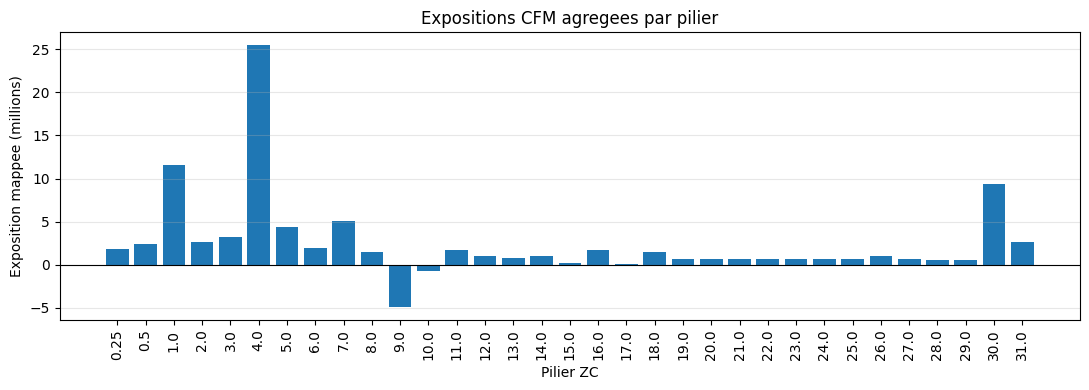

In [9]:
non_zero_exposures = exposures[exposures.abs() > 1e-9]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(non_zero_exposures.index.astype(str), non_zero_exposures.values / 1e6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Expositions CFM agregees par pilier')
ax.set_xlabel('Pilier ZC')
ax.set_ylabel('Exposition mappee (millions)')
ax.tick_params(axis='x', rotation=90)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. PnL CFM sous scenarios

In [10]:
pnl_cfm_scaled = compute_cfm_pnl_under_scenarios(exposures, scaled_df)
pnl_cfm_unscaled = compute_cfm_pnl_under_scenarios(exposures, unscaled_df)

print(f'PnL CFM FHS    : {len(pnl_cfm_scaled)} scenarios, range [{pnl_cfm_scaled.min():,.2f}, {pnl_cfm_scaled.max():,.2f}]')
print(f'PnL CFM Stress : {len(pnl_cfm_unscaled)} scenarios, range [{pnl_cfm_unscaled.min():,.2f}, {pnl_cfm_unscaled.max():,.2f}]')

PnL CFM FHS    : 2500 scenarios, range [-3,519,726.87, 4,205,771.68]
PnL CFM Stress : 520 scenarios, range [-3,067,072.57, 2,504,964.12]


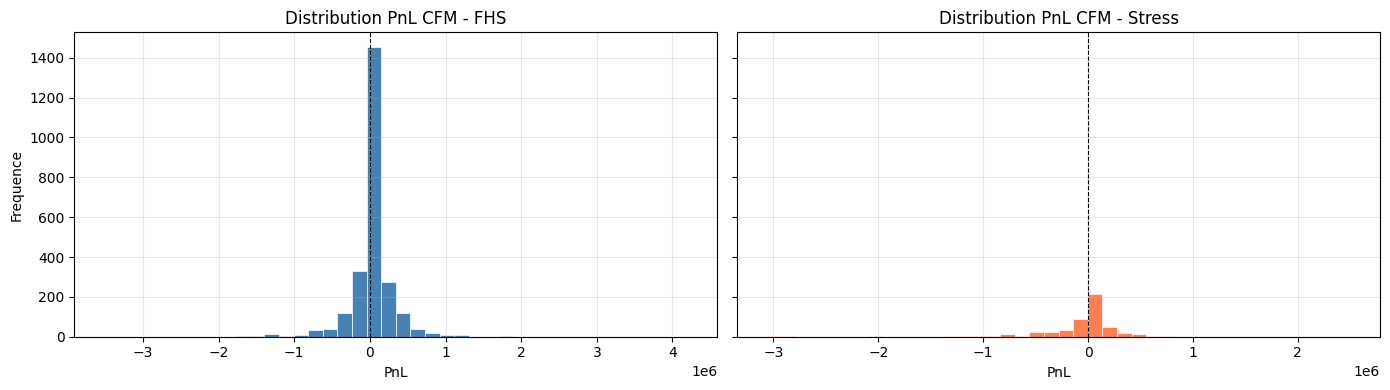

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].hist(pnl_cfm_scaled, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Distribution PnL CFM - FHS')
axes[0].set_xlabel('PnL')
axes[0].set_ylabel('Frequence')
axes[0].grid(True, alpha=0.3)

axes[1].hist(pnl_cfm_unscaled, bins=40, color='coral', edgecolor='white', linewidth=0.5)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Distribution PnL CFM - Stress')
axes[1].set_xlabel('PnL')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. ES et marge initiale CFM

In [12]:
ES_cfm_scaled = compute_es_from_pnl(pnl_cfm_scaled, alpha=config.alpha)
ES_cfm_unscaled = compute_es_from_pnl(pnl_cfm_unscaled, alpha=config.alpha)

IM_cfm = compute_initial_margin(
    es_fhs=ES_cfm_scaled,
    es_stress=ES_cfm_unscaled,
    fhs_w=config.FHS_w,
    stress_w=config.Stress_w,
)
ES_cfm_hybrid = config.FHS_w * ES_cfm_scaled + config.Stress_w * ES_cfm_unscaled

print('=' * 58)
print(f'  ES CFM FHS scale          = {ES_cfm_scaled:>14,.6f}')
print(f'  ES CFM Stress non scale   = {ES_cfm_unscaled:>14,.6f}')
print(f'  ES CFM Hybrid             = {ES_cfm_hybrid:>14,.6f}')
print(f'  MARGE INITIALE CFM        = {IM_cfm:>14,.6f}')
print(f'  IM CFM / valeur initiale  = {IM_cfm / cfm_initial_value:>14.4%}')
print('=' * 58)

  ES CFM FHS scale          = 1,647,409.508115
  ES CFM Stress non scale   = 2,738,127.847467
  ES CFM Hybrid             = 1,920,089.092953
  MARGE INITIALE CFM        = 1,920,089.092953
  IM CFM / valeur initiale  =        2.3505%


## 9. Vérification analytique de l’écart FR vs CFM



Cette section vérifie, sur un cash-flow individuel mappé sur deux piliers, la formule analytique issue de l’étude comparative FR vs CFM :

$$
\Delta PnL^{(s)}
=
MVCF \cdot \left(w_n^{FR} - W_n^{CFM}\right)
\cdot
\left(R^{(s)}(T_n) - R^{(s)}(T_{n+1})\right)
$$

où :

- $MVCF$ est la valeur de marché du cash-flow à la date d’évaluation ;
- $T_n$ et $T_{n+1}$ sont les deux piliers encadrant la maturité du cash-flow ;
- $w_n^{FR}$ est le poids implicite de la Full Revaluation sur le pilier bas ;
- $W_n^{CFM}$ est le poids CFM sur le pilier bas ;
- $R^{(s)}(T_n)$ et $R^{(s)}(T_{n+1})$ sont les returns scénario sur les deux piliers.

L’objectif est de comparer :

$$
\Delta PnL_{\text{direct}}
=
PnL_{FR}^{(s)} - PnL_{CFM}^{(s)}
$$

avec la valeur donnée par la formule analytique. L’écart numérique doit être proche de zéro.

In [13]:
# Vérification analytique de la formule d'écart FR vs CFM sur un cash-flow

import numpy as np
import pandas as pd

# Sélection d'un cash-flow réellement mappé sur deux piliers
two_leg_keys = (
    mapped.groupby(["position_id", "cashflow_maturity"])
    .filter(lambda x: x["pillar"].nunique() == 2)
    [["position_id", "cashflow_maturity"]]
    .drop_duplicates()
)

position_id = two_leg_keys.iloc[0]["position_id"]
maturity = two_leg_keys.iloc[0]["cashflow_maturity"]

legs = mapped[
    (mapped["position_id"] == position_id)
    & (mapped["cashflow_maturity"] == maturity)
].sort_values("pillar")

lower_leg = legs.iloc[0]
upper_leg = legs.iloc[1]

Tn = float(lower_leg["pillar"])
Tn1 = float(upper_leg["pillar"])

MVCF = float(lower_leg["cashflow_market_value"])
W_cfm_n = float(lower_leg["weight"])
W_cfm_n1 = float(upper_leg["weight"])

alpha = (maturity - Tn) / (Tn1 - Tn)

DF_n = current_zc_price_curve[Tn] / config.nominal
DF_n1 = current_zc_price_curve[Tn1] / config.nominal

w_fr_n = ((1 - alpha) * DF_n) / ((1 - alpha) * DF_n + alpha * DF_n1)
w_fr_n1 = (alpha * DF_n1) / ((1 - alpha) * DF_n + alpha * DF_n1)

# Scénario de test : premier scénario FHS scalé
scenario = scaled_df.iloc[0]

R_n = float(scenario[Tn])
R_n1 = float(scenario[Tn1])

# PnL FR du cash-flow
pnl_fr_cf = MVCF * (w_fr_n * R_n + w_fr_n1 * R_n1)

# PnL CFM du cash-flow
pnl_cfm_cf = MVCF * (W_cfm_n * R_n + W_cfm_n1 * R_n1)

delta_direct = pnl_fr_cf - pnl_cfm_cf

# Formule analytique
delta_formula = MVCF * (w_fr_n - W_cfm_n) * (R_n - R_n1)

diagnostic = pd.DataFrame(
    {
        "valeur": {
            "position_id": position_id,
            "cashflow_maturity": maturity,
            "Tn": Tn,
            "Tn+1": Tn1,
            "MVCF": MVCF,
            "alpha": alpha,
            "w_FR_n": w_fr_n,
            "w_FR_n+1": w_fr_n1,
            "W_CFM_n": W_cfm_n,
            "W_CFM_n+1": W_cfm_n1,
            "R(Tn)": R_n,
            "R(Tn+1)": R_n1,
            "PnL_FR_cashflow": pnl_fr_cf,
            "PnL_CFM_cashflow": pnl_cfm_cf,
            "Delta direct FR-CFM": delta_direct,
            "Delta formule": delta_formula,
            "Ecart numérique": delta_direct - delta_formula,
        }
    }
)

diagnostic

,valeur
Delta direct FR-CFM,-3.383725e+00
Delta formule,-3.383725e+00
Ecart numérique,-4.396483e-14
MVCF,1.046106e+06
PnL_CFM_cashflow,1.644525e+02
PnL_FR_cashflow,1.610688e+02
R(Tn),8.027893e-05
R(Tn+1),1.640449e-04
Tn,2.500000e-01
Tn+1,5.000000e-01


La vérification est cohérente : `Delta direct FR-CFM` et `Delta formule` sont égaux à l’arrondi numérique près. L’écart numérique vaut environ `-4.4e-14`, donc il est pratiquement nul.

Sur ce cash-flow, le PnL FR est inférieur au PnL CFM :

```text
PnL_FR  ≈ 161.07
PnL_CFM ≈ 164.45
Delta FR-CFM ≈ -3.38

## 9. Resume final

In [14]:
summary = pd.DataFrame({
    'Parametre': [
        'Date evaluation t0', 'LP', 'HP', 'SW', 'Lambda EWMA', 'Alpha ES',
        'Poids FHS', 'Poids Stress', 'Fenetre stress',
        'Nb scenarios FHS', 'Nb scenarios Stress',
        'Nb cash-flows', 'Nb jambes mappees', 'Valeur initiale CFM',
        'ES CFM FHS', 'ES CFM Stress', 'Marge Initiale CFM',
    ],
    'Valeur': [
        config.t0, config.LP, config.HP, config.SW, config.lambda_ewma, config.alpha,
        config.FHS_w, config.Stress_w, f'{config.stress_start} -> {config.stress_end}',
        len(pnl_cfm_scaled), len(pnl_cfm_unscaled),
        len(cashflows), len(mapped), f'{cfm_initial_value:,.2f}',
        f'{ES_cfm_scaled:,.6f}', f'{ES_cfm_unscaled:,.6f}', f'{IM_cfm:,.6f}',
    ],
})

summary

,Parametre,Valeur
0,Date evaluation t0,2025-05-30
1,LP,2500
2,HP,5
3,SW,60
4,Lambda EWMA,0.94
5,Alpha ES,0.99
6,Poids FHS,0.75
7,Poids Stress,0.25
8,Fenetre stress,2022-01-01 -> 2023-12-31
9,Nb scenarios FHS,2500
